In [27]:
#import libraries
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import warnings
warnings.filterwarnings('ignore')

In [28]:
#defining path
train_dir = 'dataset/' #2 classes real or AI generated

In [29]:
import sys
print(sys.executable)
import tensorflow as tf
print(tf.__version__)

c:\Users\varpi\OneDrive\Desktop\Real_vs_AI_Generated_Image_Detection\.venv311\Scripts\python.exe
2.21.0


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = (200, 200)  
BATCH = 32             

# training generator: preprocess_input + augmentation
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# validation generator: preprocess_input ONLY (no augmentation) -> honest evaluation
val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

# training object
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='binary',
    subset='training'
)

# validation data object
val_data = val_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='binary',
    subset='validation',
    shuffle=False   # keep order fixed so the confusion-matrix labels line up correctly
)

Found 2477 images belonging to 2 classes.
Found 619 images belonging to 2 classes.


In [ ]:
# build model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False  

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weight = dict(enumerate(class_weights))
print("Class indices:", train_data.class_indices) 
print("Class weights:", class_weight)

callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
]

# model compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_data,
    epochs=15,
    validation_data=val_data,
    class_weight=class_weight,
    callbacks=callbacks_phase1
)

Class indices: {'Ai_generated_dataset': 0, 'real_dataset': 1}
Class weights: {0: np.float64(0.9852824184566428), 1: np.float64(1.0151639344262295)}
Epoch 1/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 81s 974ms/step - accuracy: 0.7622 - loss: 0.5071 - val_accuracy: 0.6268 - val_loss: 0.6945 - learning_rate: 0.0010
Epoch 2/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8333 - loss: 0.3700 - val_accuracy: 0.6769 - val_loss: 0.8635 - learning_rate: 0.0010
Epoch 3/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 856ms/step - accuracy: 0.8535 - loss: 0.3316
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
78/78 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.8535 - loss: 0.3316 - val_accuracy: 0.6462 - val_loss: 1.1068 - learning_rate: 0.0010
Epoch 4/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.8668 - loss: 0.3037 - val_accuracy: 0.6866 - val_loss: 0.9086 - learning_rate: 5.0000e-04
Epoch 5/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8821 - loss: 0.2674
Epoch 5: R

In [ ]:
# --- Phase 2: fine-tune the top of ResNet-50 for extra accuracy ---
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

base_model.trainable = True
for layer in base_model.layers[:-50]:  
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
]

history_ft = model.fit(
    train_data,
    epochs=12,
    validation_data=val_data,
    class_weight=class_weight,
    callbacks=callbacks_phase2
)

Epoch 1/12
78/78 ━━━━━━━━━━━━━━━━━━━━ 218s 3s/step - accuracy: 0.8692 - loss: 0.3088 - val_accuracy: 0.7383 - val_loss: 0.9846 - learning_rate: 1.0000e-05
Epoch 2/12
78/78 ━━━━━━━━━━━━━━━━━━━━ 275s 4s/step - accuracy: 0.8906 - loss: 0.2527 - val_accuracy: 0.7092 - val_loss: 1.1351 - learning_rate: 1.0000e-05
Epoch 3/12
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9055 - loss: 0.2191
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
78/78 ━━━━━━━━━━━━━━━━━━━━ 309s 3s/step - accuracy: 0.9055 - loss: 0.2191 - val_accuracy: 0.6931 - val_loss: 1.1338 - learning_rate: 1.0000e-05
Epoch 4/12
78/78 ━━━━━━━━━━━━━━━━━━━━ 407s 5s/step - accuracy: 0.9180 - loss: 0.1996 - val_accuracy: 0.7011 - val_loss: 1.1760 - learning_rate: 5.0000e-06
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 929ms/step
                      precision    recall  f1-score   support

Ai_generated_dataset       0.87      0.57      0.69       314
        real_dataset       0.67      0.91      0.78       305

            accuracy                           0.74       619
           macro avg       0.77      0.74      0.73       619
        weighted avg       0.77      0.74      0.73       619



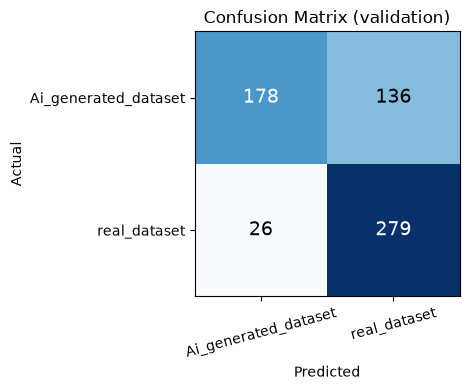

In [ ]:
# --- Evaluate the final model: confusion matrix + per-class precision / recall ---
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

val_data.reset()
y_true = val_data.classes                      
probs = model.predict(val_data, verbose=1)
y_pred = (probs.ravel() > 0.5).astype(int)    

labels = list(val_data.class_indices.keys()) 
print(classification_report(y_true, y_pred, target_names=labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix (validation)')
plt.xticks([0, 1], labels, rotation=15)
plt.yticks([0, 1], labels)
plt.xlabel('Predicted'); plt.ylabel('Actual')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
plt.tight_layout(); plt.show()

In [ ]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

img_path = 'sample.png'
img = image.load_img(img_path, target_size=(200, 200))   # must match training IMG_SIZE
img_array = image.img_to_array(img)
img_array = preprocess_input(img_array) 
img_array = np.expand_dims(img_array, axis=0)
prediction = model.predict(img_array)
if prediction[0][0] > 0.5:
    print("Prediction: Real Image")
else:
    print("Prediction: AI Generated Image")

In [35]:
model.save("project.keras")